In [ ]:
import pandas as pd
import numpy as np
from numpy import array
import re

import nltk
from nltk.corpus import stopwords

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Activation, Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from keras.preprocessing.text import one_hot
from keras.layers import GlobalMaxPooling1D

from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/4. Natural Language Processsing/MovieSentiment/IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.review[15]

"Kind of drawn in by the erotic scenes, only to realize this was one of the most amateurish and unbelievable bits of film I've ever seen. Sort of like a high school film project. What was Rosanna Arquette thinking?? And what was with all those stock characters in that bizarre supposed Midwest town? Pretty hard to get involved with this one. No lessons to be learned from it, no brilliant insights, just stilted and quite ridiculous (but lots of skin, if that intrigues you) videotaped nonsense....What was with the bisexual relationship, out of nowhere, after all the heterosexual encounters. And what was with that absurd dance, with everybody playing their stereotyped roles? Give this one a pass, it's like a million other miles of bad, wasted film, money that could have been spent on starving children or Aids in Africa....."

<Axes: xlabel='sentiment', ylabel='count'>

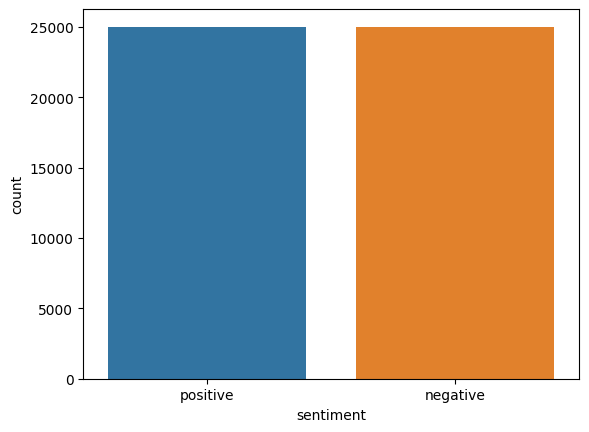

In [ ]:
import seaborn as sns

sns.countplot(x='sentiment', data=df)

In [ ]:
def preprocess_text(sen):
    # Removing html tags
    sentence = remove_tags(sen)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence

In [ ]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    return TAG_RE.sub('', text)

In [ ]:
X = []
sentences = list(df['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

In [ ]:
y = df['sentiment']

y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [ ]:
from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('/content/drive/MyDrive/4. Natural Language Processsing/MovieSentiment/glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [ ]:
embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [ ]:
print(embedding_matrix.shape)

(92547, 100)


In [ ]:
print("x_train", X_train.shape)
print("y_train", y_train.shape)
print()
print("x_test", X_test.shape)
print("y_test", y_test.shape)

x_train (40000, 100)
y_train (40000,)

x_test (10000, 100)
y_test (10000,)


In [ ]:
model = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
model.add(embedding_layer)

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 flatten_1 (Flatten)         (None, 10000)             0         
                                                                 
 dense_1 (Dense)             (None, 1)                 10001     
                                                                 
Total params: 9,264,701
Trainable params: 10,001
Non-trainable params: 9,254,700
_________________________________________________________________
None


In [ ]:
X_train

array([[   4,    1,  296, ...,  198,  345, 3812],
       [   1,  412,  100, ...,   82,   99,    6],
       [ 128, 1307,  108, ...,    0,    0,    0],
       ...,
       [ 778,    8,   24, ...,    0,    0,    0],
       [   8,  347,   10, ...,    0,    0,    0],
       [ 274,  100,  121, ...,   67,   69, 1946]], dtype=int32)

In [ ]:
history = model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 [==============================] - 2s 5ms/step - loss: 0.6105 - acc: 0.6634 - val_loss: 0.5408 - val_acc: 0.7250
Epoch 2/6
250/250 [==============================] - 1s 3ms/step - loss: 0.5024 - acc: 0.7558 - val_loss: 0.5195 - val_acc: 0.7420
Epoch 3/6
250/250 [==============================] - 1s 3ms/step - loss: 0.4632 - acc: 0.7824 - val_loss: 0.5175 - val_acc: 0.7451
Epoch 4/6
250/250 [==============================] - 1s 3ms/step - loss: 0.4382 - acc: 0.7973 - val_loss: 0.5194 - val_acc: 0.7450
Epoch 5/6
250/250 [==============================] - 1s 3ms/step - loss: 0.4266 - acc: 0.8036 - val_loss: 0.5431 - val_acc: 0.7340
Epoch 6/6
250/250 [==============================] - 1s 3ms/step - loss: 0.4099 - acc: 0.8148 - val_loss: 0.5328 - val_acc: 0.7405


In [ ]:
score = model.evaluate(X_test, y_test, verbose=1)

313/313 [==============================] - 0s 1ms/step - loss: 0.5331 - acc: 0.7430


In [ ]:
print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.533091127872467
Test Accuracy: 0.7429999709129333


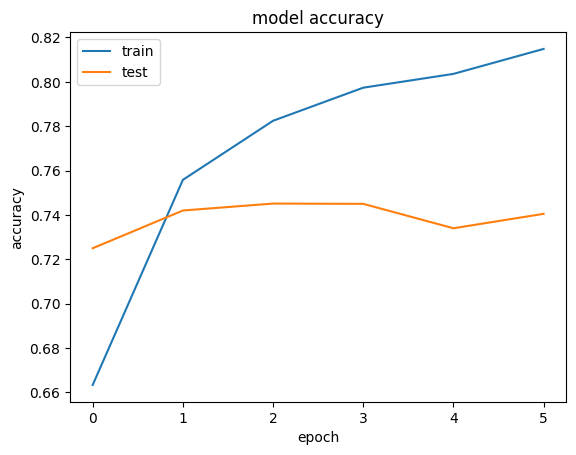

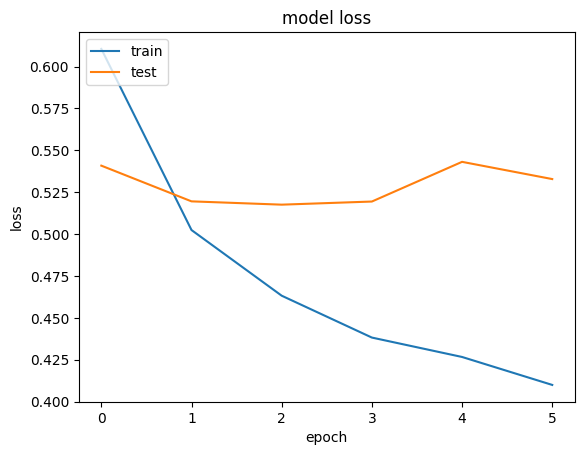

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.layers import Conv1D

model = Sequential()

embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
model.add(embedding_layer)

model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
print(model.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 conv1d (Conv1D)             (None, 96, 128)           64128     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9,318,957
Trainable params: 64,257
Non-trainable params: 9,254,700
_________________________________________________________________
None


In [ ]:
history = model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 20s 77ms/step - loss: 0.4901 - acc: 0.7643 - val_loss: 0.3929 - val_acc: 0.8209
Epoch 2/6
250/250 [==============================] - 17s 67ms/step - loss: 0.3645 - acc: 0.8412 - val_loss: 0.3610 - val_acc: 0.8359
Epoch 3/6
250/250 [==============================] - 20s 81ms/step - loss: 0.3174 - acc: 0.8639 - val_loss: 0.3528 - val_acc: 0.8389
Epoch 4/6
250/250 [==============================] - 17s 68ms/step - loss: 0.2788 - acc: 0.8852 - val_loss: 0.3384 - val_acc: 0.8474
Epoch 5/6
250/250 [==============================] - 17s 66ms/step - loss: 0.2464 - acc: 0.9014 - val_loss: 0.3575 - val_acc: 0.8405
Epoch 6/6
313/313 [==============================] - 3s 10ms/step - loss: 0.4267 - acc: 0.8139


In [ ]:
print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.4267076253890991
Test Accuracy: 0.8138999938964844


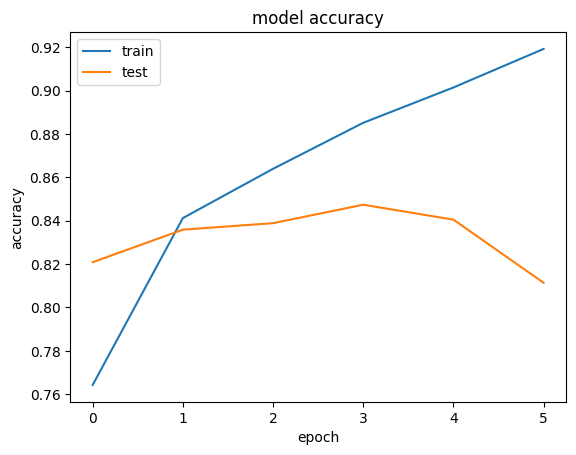

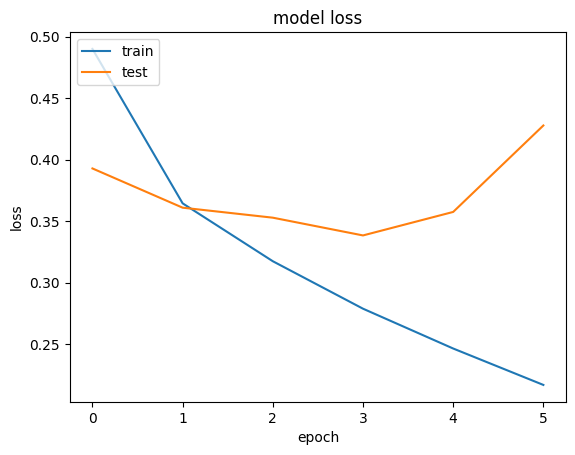

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

#Text Classification with Recurrent Neural Network (LSTM)

In [ ]:
from tensorflow.keras.layers import LSTM

model = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
model.add(embedding_layer)
model.add(LSTM(128))

model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
print(model.summary())

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 lstm_1 (LSTM)               (None, 128)               117248    
                                                                 
 dense_4 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9,372,077
Trainable params: 117,377
Non-trainable params: 9,254,700
_________________________________________________________________
None


In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.12.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, jax, keras, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine-rl


In [ ]:
history = model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 60s 232ms/step - loss: 0.5601 - acc: 0.7100 - val_loss: 0.5073 - val_acc: 0.7433
Epoch 2/6
250/250 [==============================] - 55s 219ms/step - loss: 0.4574 - acc: 0.7862 - val_loss: 0.4256 - val_acc: 0.7971
Epoch 3/6
250/250 [==============================] - 54s 214ms/step - loss: 0.4080 - acc: 0.8144 - val_loss: 0.3791 - val_acc: 0.8299
Epoch 4/6
250/250 [==============================] - 54s 214ms/step - loss: 0.3738 - acc: 0.8320 - val_loss: 0.3607 - val_acc: 0.8438
Epoch 5/6
250/250 [==============================] - 54s 217ms/step - loss: 0.3539 - acc: 0.8427 - val_loss: 0.3482 - val_acc: 0.8470
Epoch 6/6
313/313 [==============================] - 11s 36ms/step - loss: 0.3388 - acc: 0.8478


In [ ]:
print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.338807076215744
Test Accuracy: 0.8478000164031982


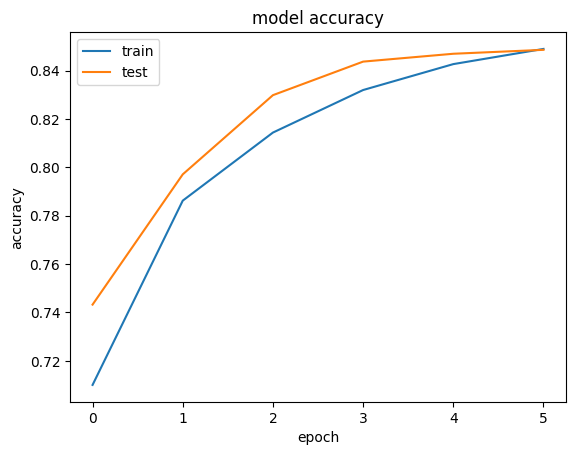

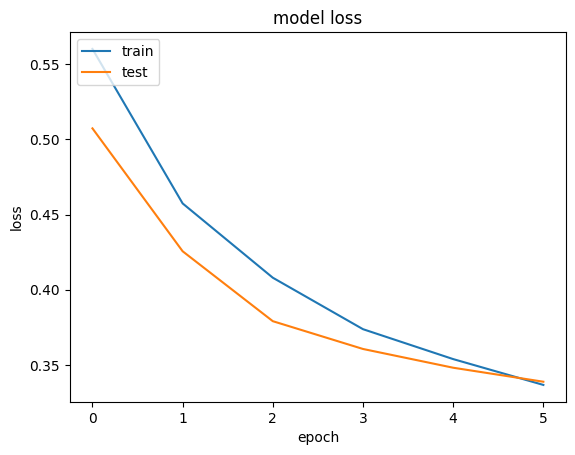

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#Making Predictions on Single Instance

In [ ]:
instance = X[57]
print(instance)

I laughed all the way through this rotten movie It so unbelievable woman leaves her husband after many years of marriage has breakdown in front of real estate office What happens The office manager comes outside and offers her job Hilarious Next thing you know the two women are going at it Yep they re lesbians Nothing rings true in this Lifetime for Women with nothing better to do movie Clunky dialogue like don want to spend the rest of my life feeling like had chance to be happy and didn take it doesn help There a wealthy distant mother who disapproves of her daughter new relationship sassy black maid unbelievable that in the year film gets made in which there a sassy black maid Hattie McDaniel must be turning in her grave The woman has husband who freaks out and wants custody of the snotty teenage kids Sheesh No cliche is left unturned 


In [ ]:
instance = tokenizer.texts_to_sequences(instance)

flat_list = []
for sublist in instance:
    for item in sublist:
        flat_list.append(item)

flat_list = [flat_list]

instance = pad_sequences(flat_list, padding='post', maxlen=maxlen)

model.predict(instance)

1/1 [==============================] - 0s 343ms/step


array([[0.63263714]], dtype=float32)

#CNN-LSTM

In [ ]:
CNN_LSTM = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
CNN_LSTM.add(embedding_layer)
CNN_LSTM.add(Conv1D(128, 5, activation='relu'))
CNN_LSTM.add(LSTM(128))

CNN_LSTM.add(Dense(1, activation='sigmoid'))
CNN_LSTM.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
CNN_LSTM.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_10 (Embedding)    (None, 100, 100)          9254700   
                                                                 
 conv1d_6 (Conv1D)           (None, 96, 128)           64128     
                                                                 
 lstm_5 (LSTM)               (None, 128)               131584    
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9,450,541
Trainable params: 195,841
Non-trainable params: 9,254,700
_________________________________________________________________


In [ ]:
history = CNN_LSTM.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = CNN_LSTM.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 80s 308ms/step - loss: 0.5778 - acc: 0.6933 - val_loss: 0.4742 - val_acc: 0.7821
Epoch 2/6
250/250 [==============================] - 84s 335ms/step - loss: 0.4331 - acc: 0.8028 - val_loss: 0.3996 - val_acc: 0.8217
Epoch 3/6
250/250 [==============================] - 76s 305ms/step - loss: 0.3734 - acc: 0.8377 - val_loss: 0.4369 - val_acc: 0.8145
Epoch 4/6
250/250 [==============================] - 80s 319ms/step - loss: 0.3487 - acc: 0.8501 - val_loss: 0.3528 - val_acc: 0.8409
Epoch 5/6
250/250 [==============================] - 84s 337ms/step - loss: 0.3030 - acc: 0.8729 - val_loss: 0.3498 - val_acc: 0.8533
Epoch 6/6
313/313 [==============================] - 13s 42ms/step - loss: 0.4666 - acc: 0.8099


In [ ]:
print("Test Score (CNN_LSTM):", score[0])
print("Test Accuracy (CNN_LSTM):", score[1])

Test Score (CNN_LSTM): 0.4665548801422119
Test Accuracy (CNN_LSTM): 0.8098999857902527


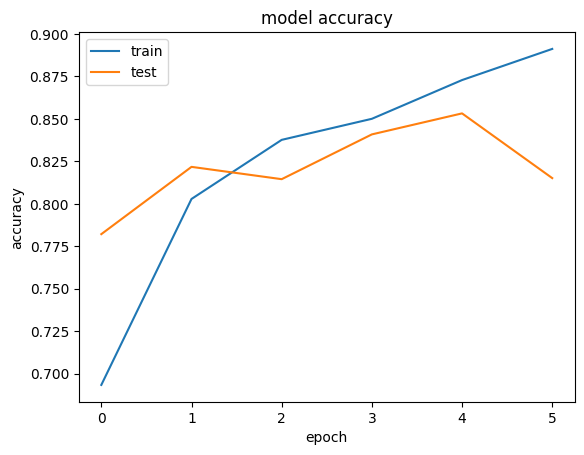

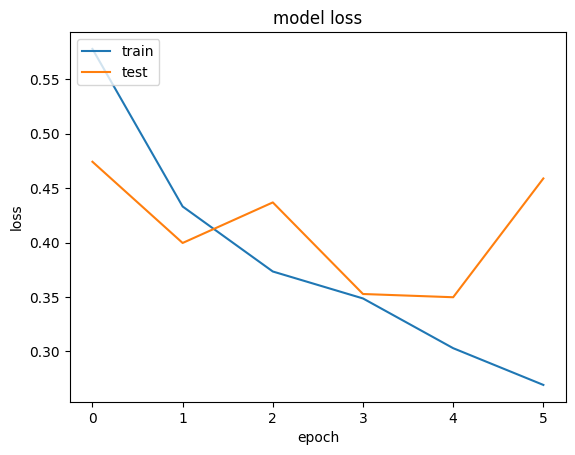

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#BLSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional

BLSTM = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
BLSTM.add(embedding_layer)
BLSTM.add(Bidirectional(LSTM(128)))

BLSTM.add(Dense(1, activation='sigmoid'))
BLSTM.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
BLSTM.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_13 (Embedding)    (None, 100, 100)          9254700   
                                                                 
 bidirectional_1 (Bidirectio  (None, 256)              234496    
 nal)                                                            
                                                                 
 dense_9 (Dense)             (None, 1)                 257       
                                                                 
Total params: 9,489,453
Trainable params: 234,753
Non-trainable params: 9,254,700
_________________________________________________________________


In [ ]:
history = BLSTM.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = BLSTM.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 99s 397ms/step - loss: 0.2996 - acc: 0.8723 - val_loss: 0.3623 - val_acc: 0.8400
Epoch 2/6
250/250 [==============================] - 101s 405ms/step - loss: 0.2839 - acc: 0.8783 - val_loss: 0.3320 - val_acc: 0.8574
Epoch 3/6
250/250 [==============================] - 100s 402ms/step - loss: 0.2629 - acc: 0.8892 - val_loss: 0.3489 - val_acc: 0.8485
Epoch 4/6
250/250 [==============================] - 102s 408ms/step - loss: 0.2360 - acc: 0.9022 - val_loss: 0.3617 - val_acc: 0.8459
Epoch 5/6
250/250 [==============================] - 99s 397ms/step - loss: 0.2172 - acc: 0.9116 - val_loss: 0.3610 - val_acc: 0.8521
Epoch 6/6
313/313 [==============================] - 19s 61ms/step - loss: 0.3720 - acc: 0.8530


In [ ]:
print("Test Score (CNN_LSTM):", score[0])
print("Test Accuracy (CNN_LSTM):", score[1])

Test Score (CNN_LSTM): 0.371979683637619
Test Accuracy (CNN_LSTM): 0.8529999852180481


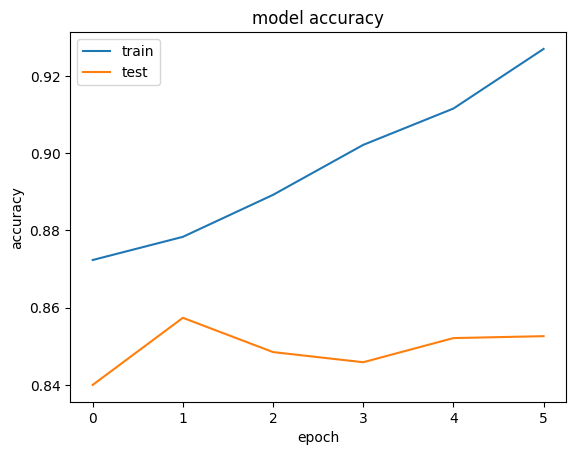

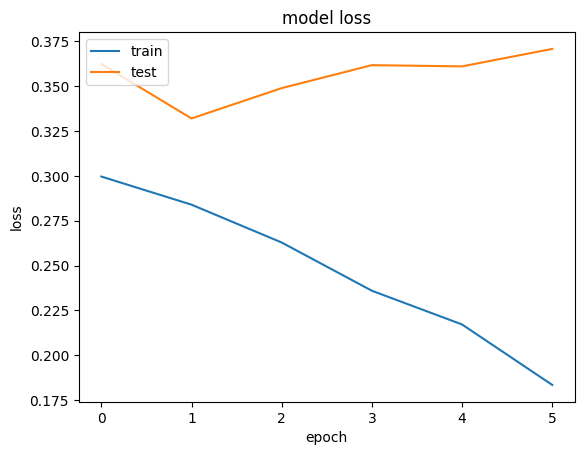

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()